## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
- Regression is used when we want to predict a numerical value, while classification is used when we want to predict a category or class. For example, predicting how many cars will be sold would be a regression problem because sales are numeric. Predicting whether a vehicle is a car, truck, SUV, or van would be a classification problem.

2. What is a confusion table? What does it help us understand about a model's performance?
- It compares the model's predicted classes with the actual classes. Correct predictions appear along the diagonal, while the other cells show where the model made mistakes. This is helpful because accuracy alone only tells us how often the model was correct, while a confusion table shows what types of mistakes the model is making, such as false positives and false negatives.

3. What does the SSE quantify about a particular model?
- It measures the total amount of prediction error made by a regression model. It takes the difference between each actual value and predicted value, squares those differences, and adds them together. A smaller SSE generally means the model's predictions are closer to the actual values, while a larger SSE means the model is making larger errors.

4. What are overfitting and underfitting?
- Overfitting happens when a model follows the training data too closely, including some of its noise or random patterns. Because of this, it can perform very well on the training data but poorly on new data. Underfitting is the opposite: the model is too simple and misses important patterns in the data, so it performs poorly even on the general trend. With kNN, a very small (k) can lead to overfitting, while a very large (k) can cause underfitting because too many neighbors are averaged together.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
- Splitting the data lets us train the model on one group of observations and then see how well it works on data it has not already seen. If we only looked at performance on the training data, we might choose a model that simply fits that data extremely well but does not generalize to new observations. By comparing different values of (k) using accuracy for classification or SSE for regression on held-out data, we can choose a (k) that does a better job balancing overfitting and underfitting. More specifically, the data used to choose (k) is usually called the validation set. A separate test set should ideally be saved until the end so that we can get an unbiased final estimate of how well the chosen model performs on new data.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
- A class label gives one clear prediction, such as "truck." Its main strength is that it is simple and easy to understand or act on. The weakness is that it does not show how confident the model is. A model that thinks something is 51% likely to be a truck and a model that thinks it is 99% likely to be a truck would both just return "truck." A probability distribution gives more information by showing how likely each possible class is. For example, it might say 60% truck, 30% SUV, and 10% car. This helps us understand the model's uncertainty and lets us make decisions using different probability thresholds. The downside is that probability distributions are more complicated to interpret, and the probabilities themselves may not always perfectly represent the model's true level of confidence. In kNN specifically, these probabilities can be estimated using the proportion of the (k) nearest neighbors that belong to each class.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

Shape: (338, 4)

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64

Mine type counts:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature summary:
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000


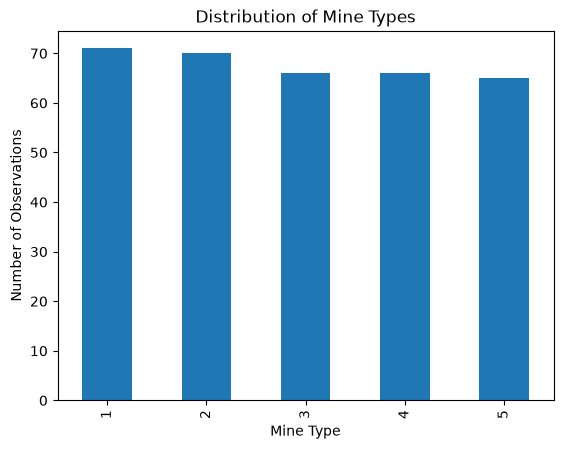

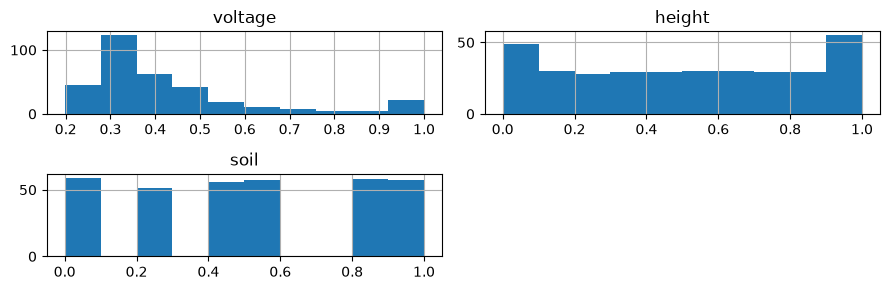

In [11]:
# 1


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the data
df = pd.read_csv("land_mines.csv")

df.head()

# Basic information about the data
print("Shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nMine type counts:")
print(df["mine_type"].value_counts().sort_index())

print("\nFeature summary:")
print(df[["voltage", "height", "soil"]].describe())

# Visualize the distribution of the target
df["mine_type"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Mine Type")
plt.ylabel("Number of Observations")
plt.title("Distribution of Mine Types")
plt.show()

# Look at the feature distributions
df[["voltage", "height", "soil"]].hist(figsize=(9, 3))
plt.tight_layout()
plt.show()

The dataset has 338 observations and 4 columns, with no missing values. The target variable, mine_type, contains five classes. The classes are fairly balanced: mine type 1 has 71 observations, type 2 has 70, types 3 and 4 each have 66, and type 5 has 65.

The three predictors are voltage, height, and soil. Voltage ranges from about 0.198 to 1.0, height ranges from 0 to 1, and soil takes values from 0 to 1 in increments of 0.2. Since none of the classes completely dominate the data, each mine type has a reasonable number of examples for training and testing.

In [12]:
# 2

X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.50,
    random_state=42,
    stratify=y
)

print("Training size:", len(X_train))
print("Test size:", len(X_test))

print("\nTraining class counts:")
print(y_train.value_counts().sort_index())

print("\nTest class counts:")
print(y_test.value_counts().sort_index())

Training size: 169
Test size: 169

Training class counts:
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64

Test class counts:
mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64


I split the data 50/50, so there are 169 observations in the training set and 169 in the test set. I also used stratify=y so that all five mine types stayed represented in roughly the same proportions in both sets. This is useful here because the dataset is fairly small, and I did not want one class to randomly end up mostly in one half of the data.

Best k: 1
Best accuracy: 0.46153846153846156


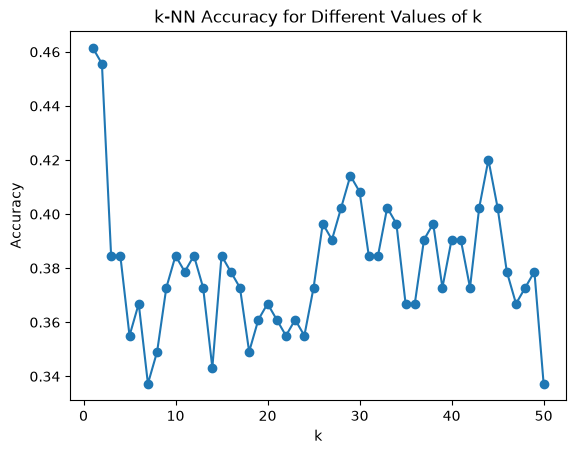

In [13]:
# 3


k_values = range(1, 51)
accuracies = []

for k in k_values:

    model = Pipeline([
        ("scaler", MinMaxScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracies.append(
        accuracy_score(y_test, y_pred)
    )

accuracy_results = pd.DataFrame({
    "k": k_values,
    "accuracy": accuracies
})

# Find the k with the highest accuracy
best_row = accuracy_results.loc[
    accuracy_results["accuracy"].idxmax()
]

best_k = int(best_row["k"])
best_accuracy = best_row["accuracy"]

print("Best k:", best_k)
print("Best accuracy:", best_accuracy)

# Plot accuracy against k
plt.plot(
    accuracy_results["k"],
    accuracy_results["accuracy"],
    marker="o"
)

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy for Different Values of k")
plt.show()

Since k-NN makes predictions based on the distances between observations, I scaled the features before fitting the models. I then tried values of (k) from 1 through 50 and compared their accuracy on the held-out test/validation data. The best-performing value was (k=1), with a test accuracy of about: 46.15%. k-NN classifies an observation based on the classes of its nearest neighbors; with uniform weighting, the class with the most representatives among those neighbors is selected. I selected (k) by comparing the accuracy for each possible value. Small values of (k) create a more flexible model, while larger values use more neighboring observations and make the predictions smoother. In this particular split, (k=1) produced the highest accuracy.

In [14]:
# 4

# Build the final model using the optimal k
final_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

labels = [1, 2, 3, 4, 5]

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

confusion_table = pd.DataFrame(
    cm,
    index=["Actual 1", "Actual 2", "Actual 3", "Actual 4", "Actual 5"],
    columns=[
        "Predicted 1",
        "Predicted 2",
        "Predicted 3",
        "Predicted 4",
        "Predicted 5"
    ]
)

confusion_table

Accuracy: 0.46153846153846156


,Predicted 1,Predicted 2,Predicted 3,Predicted 4,Predicted 5
Actual 1,21,0,4,4,7
Actual 2,0,32,0,3,0
Actual 3,8,0,7,10,8
Actual 4,7,5,4,11,6
Actual 5,7,0,9,9,7


The model correctly predicted 78 out of 169 observations, giving an overall accuracy of approximately 46.15%, representing the fraction of observations that were classified correctly. Type 2 performs by far the best. The model correctly identifies 32 of the 35 actual type-2 mines, or about 91.4%. Type 1 performs reasonably compared with the remaining classes, correctly identifying 21 of 36, or about 58.3%. However, the model has much more difficulty with types 3, 4, and 5. There is also a clear pattern of confusion among these classes. For example, 10 actual type-3 mines are classified as type 4, while actual type-5 mines are frequently classified as either type 3 or type 4.

5. One important issue is that just looking at how many mines of one type were correctly identified does not tell the whole story. We also need to ask, when the model predicts a particular mine type, how often is that prediction actually correct? Because this would be used in something as dangerous as land-mine removal, I would not use this model as the final decision maker. An overall accuracy of about 46% is not strong enough for someone to safely rely on the prediction by itself.

Instead, I would use it as an additional screening or decision-support tool alongside other sensors, expert judgment, and physical inspection procedures. I would especially be cautious with predictions of types 3, 4, and 5 because the confusion table shows that the model has a hard time distinguishing between them.

The main takeaway for me is that the type of mistake matters just as much as overall accuracy. In a safety-critical situation, even a model that gets many predictions right can still be dangerous if the incorrect predictions lead someone to treat a mine as the wrong type. I would want more training data or additional useful features before trusting this model for real-world decisions.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Mouad Tazka

**Date:** October 2, 2026

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [15]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]